# Visualization of Multi-Stock Trading Results

This notebook creates a comprehensive visualization of trading results for an agent trading multiple stocks. It compares the DRL agent's performance against a buy-and-hold strategy, plots the cumulative returns, and marks the aggregate points where trades (buys or sells) occurred across the entire portfolio.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import numpy as np

### Load Data

Load the agent's performance data, the trading actions, and the buy-and-hold benchmark data from the pickle files.

In [40]:
# Load agent's account value history
with open('aapl_rl_df_account_value_ppo.pkl', 'rb') as f:
    df_account_value = pickle.load(f)

# Load agent's trading actions
with open('aapl_rl_df_actions_ppo.pkl', 'rb') as f:
    df_actions = pickle.load(f)

# Load buy-and-hold benchmark data
with open('results/aronrl_nas.pkl', 'rb') as f:
    buy_and_hold = pickle.load(f)

In [41]:
df_actions.iloc[20:30]

,date,actions
20,2024-08-29,[0]
21,2024-08-30,[0]
22,2024-09-03,[0]
23,2024-09-04,[-93]
24,2024-09-05,[92]
25,2024-09-06,[0]
26,2024-09-09,[-310]
27,2024-09-10,[312]
28,2024-09-11,[0]
29,2024-09-12,[0]


### Data Preparation & Calculation

This section prepares the data for plotting. It involves:
1.  Converting date columns and indices to datetime objects.
2.  Calculating the cumulative return for both the DRL agent and the buy-and-hold strategy.
3.  Processing the `df_actions` DataFrame to identify aggregate buy and sell days and calculate total daily volumes.

In [42]:
# 1. Prepare DRL Strategy Returns
df_drl_returns = df_account_value.copy()
df_drl_returns['date'] = pd.to_datetime(df_drl_returns['date'])
df_drl_returns.set_index('date', inplace=True)
initial_value_drl = df_drl_returns['account_value'].iloc[0]
df_drl_returns['cumulative_return'] = (df_drl_returns['account_value'] / initial_value_drl - 1) * 100

# 2. Prepare Buy & Hold Returns
df_bh_returns = buy_and_hold.copy()
df_bh_returns.index = pd.to_datetime(df_bh_returns.index)
# Ensure buy & hold data aligns with the DRL strategy's dates
df_bh_returns = df_bh_returns.reindex(df_drl_returns.index).ffill()
initial_value_bh = df_bh_returns['close'].iloc[0]
df_bh_returns['cumulative_return'] = (df_bh_returns['close'] / initial_value_bh - 1) * 100

# 3. Process Multi-Stock Actions
actions_df = df_actions.copy()
actions_df.index = pd.to_datetime(actions_df.index)

# Calculate total daily buy and sell volumes
# A buy is any positive value, a sell is any negative value.
actions_df['buy_volume'] = actions_df[actions_df > 0].sum(axis=1)
actions_df['sell_volume'] = np.abs(actions_df[actions_df < 0].sum(axis=1))

# Identify days with any buy or sell action
buy_days = actions_df[actions_df['buy_volume'] > 0]
sell_days = actions_df[actions_df['sell_volume'] > 0]

print("Data preparation complete. Found:")
print(f"- {len(buy_days)} days with buy actions.")
print(f"- {len(sell_days)} days with sell actions.")

TypeError: '>' not supported between instances of 'str' and 'int'

### Create Plot with Trade Points

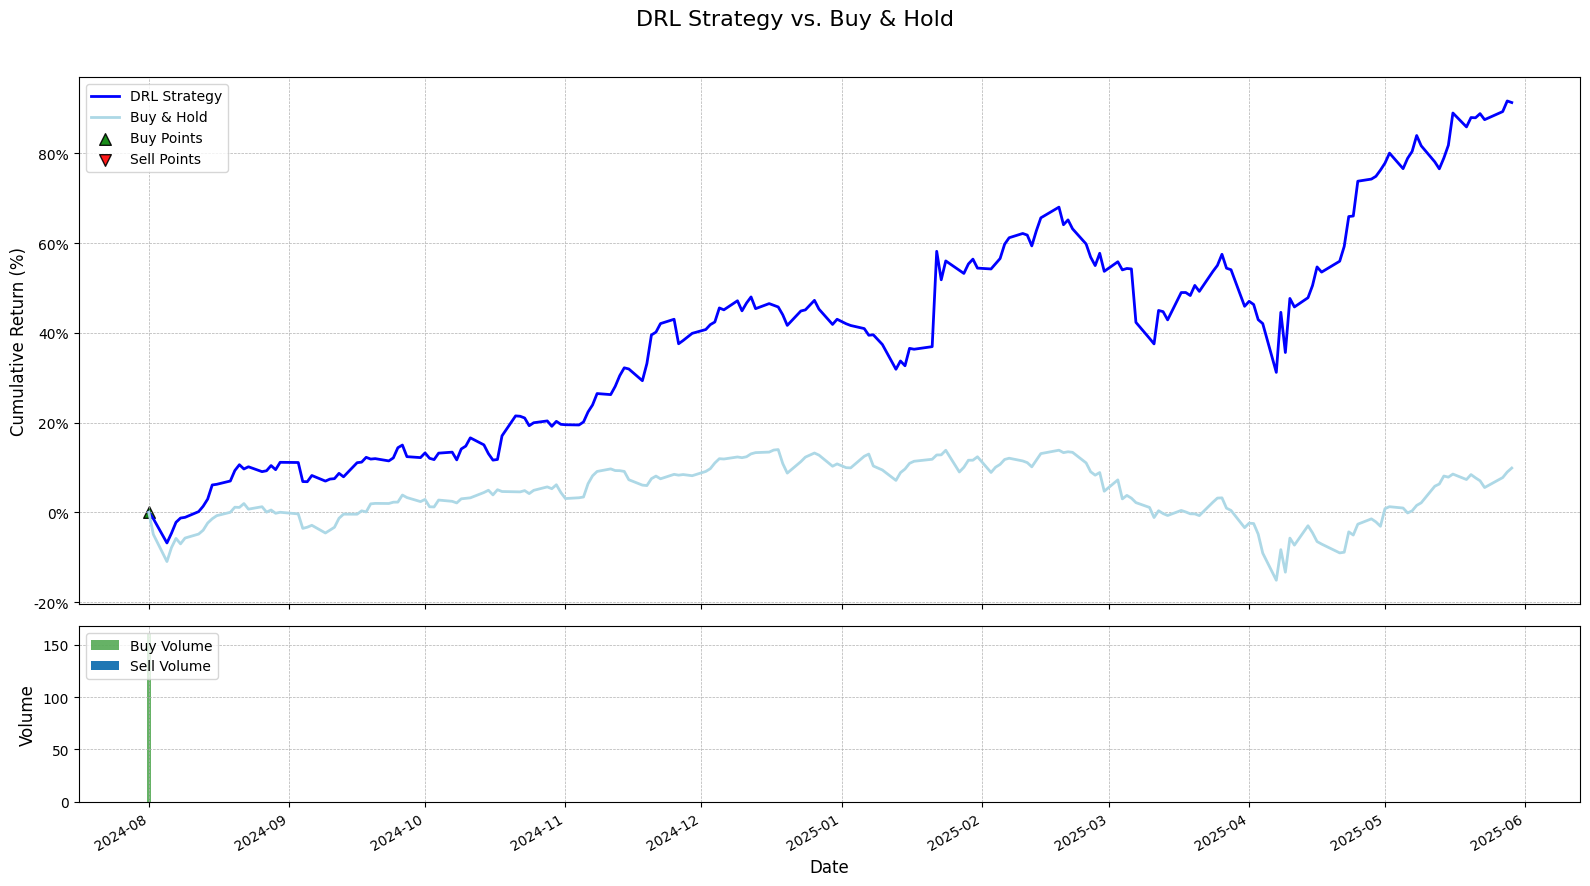

In [38]:
# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
fig.suptitle('DRL Strategy vs. Buy & Hold', fontsize=16)

# --- Panel 1: Cumulative Returns and Trade Markers ---

# Plot the main return lines
ax1.plot(df_drl_returns.index, df_drl_returns['cumulative_return'], color='blue', label='DRL Strategy', linewidth=2)
ax1.plot(df_bh_returns.index, df_bh_returns['cumulative_return'], color='lightblue', label='Buy & Hold', linewidth=2)

# Add markers for buy and sell points
# The y-value for the marker is the cumulative return of the DRL strategy on that day
ax1.scatter(buy_days.index, df_drl_returns.loc[buy_days.index, 'cumulative_return'], 
            color='green', marker='^', s=70, label='Buy Points', alpha=0.9, edgecolors='black')
ax1.scatter(sell_days.index, df_drl_returns.loc[sell_days.index, 'cumulative_return'], 
            color='red', marker='v', s=70, label='Sell Points', alpha=0.9, edgecolors='black')

# Formatting for the top panel
ax1.set_ylabel('Cumulative Return (%)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(round(x))}%'))
ax1.grid(True, which='major', linestyle='--', linewidth=0.5)
ax1.legend(loc='upper left')

# --- Panel 2: Trading Volume ---

# Plot the buy and sell volumes as bar charts
ax2.bar(buy_days.index, buy_days['buy_volume'], color='green', alpha=0.6, label='Buy Volume', width=0.8)
ax2.bar(sell_days.index, sell_days['sell_volume'], color='red', alpha=0.6, label='Sell Volume', width=0.8)

# Formatting for the bottom panel
ax2.set_ylabel('Volume', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, which='major', linestyle='--', linewidth=0.5)
ax2.legend(loc='upper left')

# --- General Figure Formatting ---

# Format the x-axis to display dates nicely
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
fig.autofmt_xdate() # Auto-rotate date labels

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
plt.show()